In [1]:
# !pip install torch
# !pip install torchvision


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Hyperparameters
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Recommended code block to check CUDA details ---

# Check if CUDA (GPU support) is available
if device == "cuda":
    # Get the number of available GPUs
    gpu_count = torch.cuda.device_count()
    print(f"CUDA is available. Using {gpu_count} GPU(s).")
    
    # Print the name of each GPU
    for i in range(gpu_count):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("CUDA not available. Using CPU.")

# --- End of recommended block ---


lr = 2e-4  # Learning rate
batch_size = 128
image_size = 64
channels_img = 1 # MNIST is grayscale
z_dim = 100 # Latent dimension (noise)
num_epochs = 50 # As required by the assignment

# Quick fix: Renamed 'transforms' variable to avoid conflict with the module
transform_pipeline = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5 for _ in range(channels_img)], [0.5 for _ in range(channels_img)]),
])

dataset = datasets.MNIST(root="dataset/", train=True, transform=transform_pipeline, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,num_workers=4 )

CUDA is available. Using 1 GPU(s).
  GPU 0: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            nn.ConvTranspose2d(z_dim, features_g * 16, 4, 1, 0, bias=False), # N x f_g*16 x 4 x 4
            nn.BatchNorm2d(features_g * 16),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 16, features_g * 8, 4, 2, 1, bias=False), # N x f_g*8 x 8 x 8
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False), # N x f_g*4 x 16 x 16
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False), # N x f_g*2 x 32 x 32
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 2, channels_img, 4, 2, 1, bias=False), # N x channels_img x 64 x 64
            nn.Tanh() # Output: [-1, 1]
        )

    def forward(self, x):
        return self.net(x)

In [4]:
import torch.nn.utils.spectral_norm as spectral_norm

class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            # Input: N x channels_img x 64 x 64
            # We wrap each convolutional layer with spectral_norm
            spectral_norm(nn.Conv2d(channels_img, features_d, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(features_d * 8, 1, 4, 2, 0, bias=False)),
            nn.Sigmoid() # We go back to using Sigmoid for a 0-1 probability
        )

    def forward(self, x):
        return self.net(x)

In [5]:
# Initialize models
gen = Generator(z_dim, channels_img, 64).to(device)
disc = Discriminator(channels_img, 64).to(device)

# Optimizers
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

# Loss function
criterion = nn.BCELoss()

In [6]:
# Create a fixed noise vector to see the progression of the generator
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device) # We'll generate a grid of 8x8=64 images

In [7]:
# Before the training loop starts
G_losses = []
D_losses = []

In [8]:
# Main training loop
for epoch in range(num_epochs):
    for batch_idx, (real, _) in enumerate(loader):
        real = real.to(device)
        batch_size = real.shape[0]

        ### Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        disc.zero_grad()
        # Train with real images
        label_real = torch.ones(batch_size, 1, 1, 1).to(device)
        output_real = disc(real)
        loss_disc_real = criterion(output_real, label_real)

        # Train with fake images
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)
        label_fake = torch.zeros(batch_size, 1, 1, 1).to(device)
        output_fake = disc(fake.detach()) # .detach() to not update generator
        loss_disc_fake = criterion(output_fake, label_fake)

        loss_disc = loss_disc_real + loss_disc_fake
        loss_disc.backward()
        opt_disc.step()

        ### Train Generator: min log(1 - D(G(z))) <--> max log(D(G(z)))
        gen.zero_grad()
        output_gen = disc(fake) # Use the same fake images
        loss_gen = criterion(output_gen, label_real) # Use real labels to fool D
        loss_gen.backward()
        opt_gen.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")
    # Append the losses for plotting
    G_losses.append(loss_gen.item())
    D_losses.append(loss_disc.item())
    with torch.no_grad():
        # Generate images from the fixed noise vector
        fake_samples = gen(fixed_noise)
        
        # You can save the images or display them
        # Option 1: Save a grid of images
        from torchvision.utils import save_image
        save_image(fake_samples, f"gan_samples_SNGAN/sample_epoch_{epoch+1}.png", normalize=True)

    # Make sure you have a folder named 'gan_samples' or change the path

Epoch [1/50] Loss D: 0.2604, Loss G: 2.7986
Epoch [2/50] Loss D: 1.5366, Loss G: 0.5470
Epoch [3/50] Loss D: 0.0167, Loss G: 6.0790
Epoch [4/50] Loss D: 0.8078, Loss G: 1.3190
Epoch [5/50] Loss D: 0.5713, Loss G: 1.0208
Epoch [6/50] Loss D: 0.6385, Loss G: 1.6997
Epoch [7/50] Loss D: 0.3994, Loss G: 1.6432
Epoch [8/50] Loss D: 0.0910, Loss G: 4.4659
Epoch [9/50] Loss D: 0.4274, Loss G: 3.7493
Epoch [10/50] Loss D: 0.3123, Loss G: 3.0855
Epoch [11/50] Loss D: 0.1619, Loss G: 3.3000
Epoch [12/50] Loss D: 0.5547, Loss G: 2.2411
Epoch [13/50] Loss D: 0.0632, Loss G: 4.2258
Epoch [14/50] Loss D: 0.1323, Loss G: 2.9969
Epoch [15/50] Loss D: 0.0180, Loss G: 7.1771
Epoch [16/50] Loss D: 0.0022, Loss G: 9.1791
Epoch [17/50] Loss D: 0.0019, Loss G: 8.3371
Epoch [18/50] Loss D: 0.0029, Loss G: 7.9528
Epoch [19/50] Loss D: 0.0128, Loss G: 15.6023
Epoch [20/50] Loss D: 0.0605, Loss G: 4.8270
Epoch [21/50] Loss D: 0.0305, Loss G: 5.2176
Epoch [22/50] Loss D: 0.0291, Loss G: 5.1831
Epoch [23/50] Loss

In [9]:
!pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable


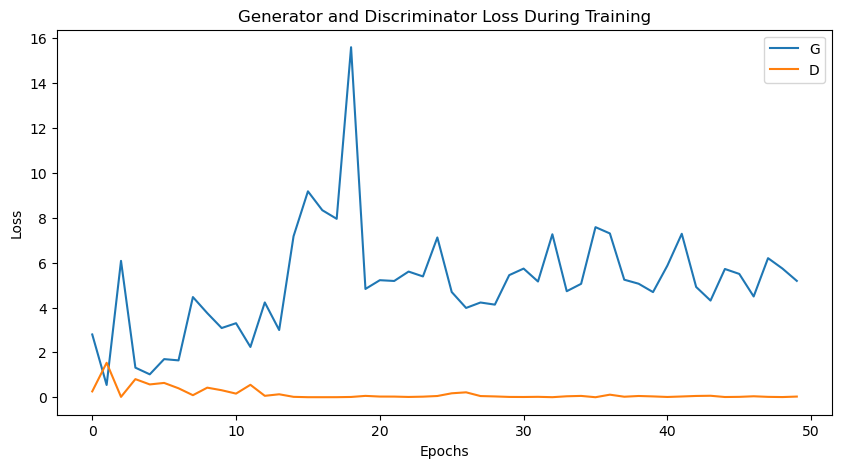

In [10]:
import matplotlib.pyplot as plt

# After the training loop finishes
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("SNGAN_loss_plot.png") # Save the plot to a file
plt.show()

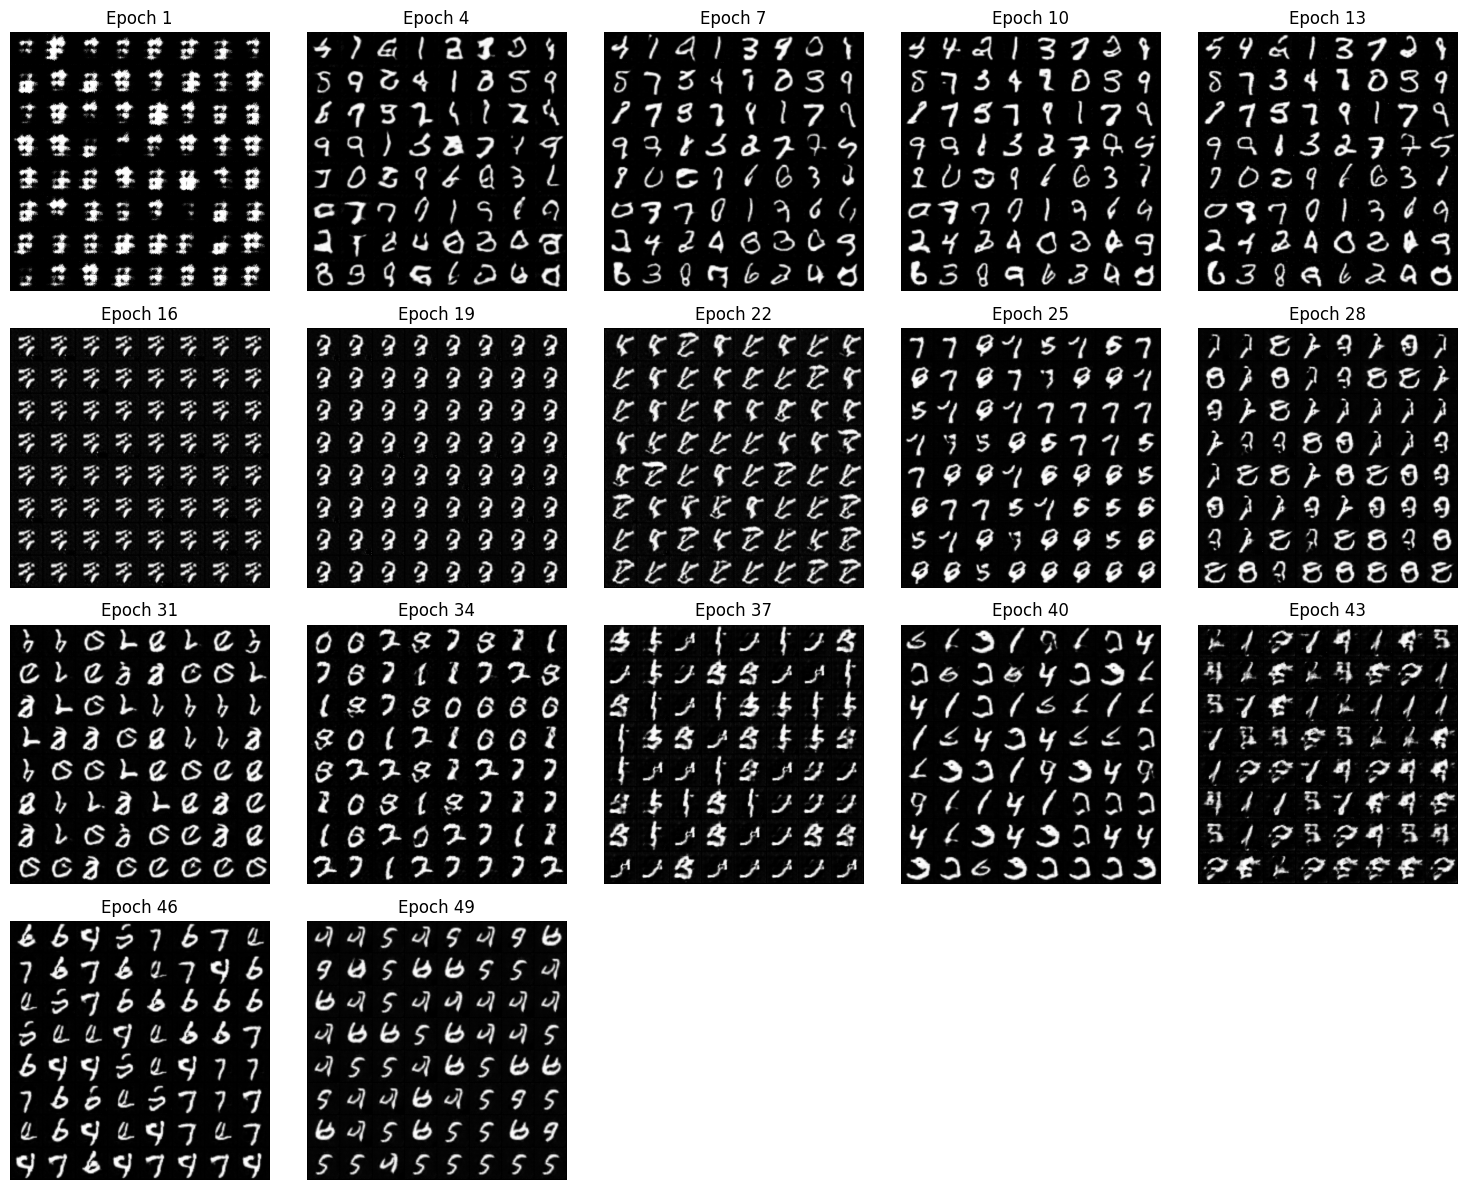

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = "gan_samples_SNGAN"
epochs = 50
step =3

# Collect epochs to display
selected_epochs = list(range(1, epochs+1, step))

# Calculate grid size
cols = 5  # number of images per row
rows = (len(selected_epochs) + cols - 1) // cols

# Prepare the figure
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))

for idx, epoch in enumerate(selected_epochs):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c] if rows > 1 else axes[c]

    img_path = os.path.join(folder, f"sample_epoch_{epoch}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"Epoch {epoch}")
    ax.axis('off')

# Turn off any empty subplots
for i in range(len(selected_epochs), rows*cols):
    r = i // cols
    c = i % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.axis('off')
plt.tight_layout()
plt.show()